In [73]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date
from sklearn.metrics import r2_score as R2S

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2023-06-14


'2023-06-14'

In [3]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

taxol = '[Paclitaxel] ' r'$(\mu M)$'#'[Taxol] ' r'$(\mu M)$' #'[Docetaxol] ' r'$(\mu M)$' #'[Epothilone D] ' r'$(\mu M)$'
tax = 'epoD'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

drug = '[Drug] ' r'$(\mu M)$'
drugtype = 'Drug Type'

nogales2018 = (1- 81.76/83.95)*100
nogales2018

2.608695652173909

In [4]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
darkyellow= '#FCF2B8'
yellow = '#FFCB05'
lightyellow = '#FCF2B8'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))


palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green]
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

StartHue3 = Color(lightyellow)
Yellowcolor = list(StartHue3.range_to(Color(darkyellow),5))
Yellowpalette = list(map(Color.get_hex,Yellowcolor))
Yellowpalette

['#fcf2b8', '#fcf2b8', '#fcf2b8', '#fcf2b8', '#fcf2b8']

## Import Kappa csv ##

In [104]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [106]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i.stem).rfind(tax) != -1]
folders

[WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH1_epoD0.1uM'),
 WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH2_epoD0.1uM')]

In [107]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('final') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH1_epoD0.1uM/1-Stack_Composite-final-1-plain.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH1_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH2_epoD0.1uM/1-Stack_Composite-final-1-plain.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH2_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv')]

In [108]:
files1 = [i for i in files if str(i).rfind('1-plain') != -1 ]
files2 = [i for i in files if str(i).rfind('2-'+tax) != -1 ]
#files3 = [i for i in files if str(i).rfind('3dcx') != -1 ]
files2

[WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH1_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-02-02_doublecap_EpoD/CH2_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv')]

In [109]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).rfind(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [110]:
dates= []
CH= []
taxl= []
dcx = []
dcxtype= []
for i in files1:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    #dcx0 = findmetadata("DCX",'nM',i)
    #dcx = dcx + [dcx0] 
    
    #type0 = findmetadata("type",'_',i)
    #dcxtype = dcxtype + [type0] 
    
    taxl0 = findmetadata(tax,'uM',i)
    taxl = taxl + [taxl0] 
    

dates,CH,dcx, dcxtype,taxl

(['2023-02-02', '2023-02-02'], ['1', '2'], [], [], ['0.1', '0.1'])

In [111]:
def keep_avg_kappa(file,i,timepoint):
    data = pd.read_csv(file, encoding='utf-8')
    
    keep_columns = ['Curve Name','Curve Length (um)']
    
    data_avg = data.drop_duplicates(subset ='Curve Length (um)', keep = 'first')
    data_avg = data_avg[keep_columns]
    
    if timepoint == 'plain':
        data_avg[taxol]=0
        data_avg[DCXconc]=0
        data_avg[Type]='None'
        
    if timepoint == 'tax':
        data_avg[taxol]=float(taxl[i])
        data_avg[DCXconc]=0
        data_avg[Type]='None'
        
#     if timepoint == 'dcx':
#         data_avg[taxol]=float(tax[i])
#         data_avg[DCXconc]=float(dcx[i])
#         data_avg[Type]=dcxtype[i]
                
        
    data_avg['Date']=dates[i]
    data_avg['CH']=CH[i]
    
    return data_avg

In [112]:
data = pd.DataFrame(columns=[] , index=[])
for i in range(0,len(files1)):
    
    data_1plain_avg = keep_avg_kappa(files1[i],i,'plain')
    data_2tax_avg = keep_avg_kappa(files2[i],i,'tax')
    #data_3dcx_avg = keep_avg_kappa(files3[i],i,'dcx')

    data0 = pd.concat([data_1plain_avg, data_2tax_avg], ignore_index=True)

    data0 = data0.sort_values(['Curve Name',taxol,DCXconc])

    data = pd.concat([data,data0], ignore_index=True)

In [113]:
data

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,7.927621,0.0,0,None,2023-02-02,1
1,CURVE 1,8.110583,0.1,0,None,2023-02-02,1
2,CURVE 2,9.059712,0.0,0,None,2023-02-02,1
3,CURVE 2,9.263397,0.1,0,None,2023-02-02,1
4,CURVE 3,9.247815,0.0,0,None,2023-02-02,1
5,CURVE 3,9.321196,0.1,0,None,2023-02-02,1
6,CURVE 1,8.020421,0.0,0,None,2023-02-02,2
7,CURVE 1,8.268629,0.1,0,None,2023-02-02,2
8,CURVE 10,5.922948,0.0,0,None,2023-02-02,2
9,CURVE 10,6.067056,0.1,0,None,2023-02-02,2


In [114]:
path.parents[1]

WindowsPath('D:/Sofia')

In [115]:
newdirectory = str(path.parents[0])+'//Expansion_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets')

In [116]:
name = dates[0]+'_EpoD_expansion_analysed-on_'+date_today +'.csv'
name

'2023-02-02_EpoD_expansion_analysed-on_2023-02-03.csv'

In [117]:
data.to_csv(path/(name), encoding='utf-8', index=False)
data.to_csv(newmydir/(name), encoding='utf-8', index=False)

### JOIN ###

In [118]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [119]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if str(i).rfind('EpoD') != -1]
files = [i for i in files if str(i).rfind('Sheet.csv') == -1 if str(i).rfind('csv') != -1]
files

[WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-19_EpoD_expansion_analysed-on_2023-02-01.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-24_EpoD_expansion_analysed-on_2023-02-01.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-25_EpoD_expansion_analysed-on_2023-02-01.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-02-02_EpoD_expansion_analysed-on_2023-02-03.csv')]

In [120]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata.to_csv(path/('jointdata-on_'+date_today +'_Doce_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,11.829896,0.0,0,None,2023-01-19,1
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1
2,CURVE 2,7.579007,0.0,0,None,2023-01-19,1
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1
4,CURVE 3,6.910134,0.0,0,None,2023-01-19,1
...,...,...,...,...,...,...,...
135,CURVE 7,7.613788,0.1,0,None,2023-02-02,2
136,CURVE 8,6.447007,0.0,0,None,2023-02-02,2
137,CURVE 8,6.560230,0.1,0,None,2023-02-02,2
138,CURVE 9,7.460709,0.0,0,None,2023-02-02,2


In [121]:
# plainData = joindata.iloc[:-2:3]
# taxData = joindata.iloc[1:-1:3]
# dcxData = joindata.iloc[2::3]
plainData = joindata.iloc[:-1:2]
taxData = joindata.iloc[1::2]

In [122]:
taxData

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1
...,...,...,...,...,...,...,...
131,CURVE 5,7.561172,0.1,0,None,2023-02-02,2
133,CURVE 6,5.221171,0.1,0,None,2023-02-02,2
135,CURVE 7,7.613788,0.1,0,None,2023-02-02,2
137,CURVE 8,6.560230,0.1,0,None,2023-02-02,2


In [123]:
def percent_expansion(beforeData, afterData):
    ratio = beforeData['Curve Length (um)'].values / afterData['Curve Length (um)'].values
    prcnt_expansion = (1- ratio)*100
    afterData['Expansion %'] = prcnt_expansion
    return afterData

In [124]:
percent_expansion(plainData, taxData)
#percent_expansion(plainData, dcxData)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH,Expansion %
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1,2.581796
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1,2.509758
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1,1.455021
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1,2.573112
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1,2.423518
...,...,...,...,...,...,...,...,...
131,CURVE 5,7.561172,0.1,0,None,2023-02-02,2,2.294891
133,CURVE 6,5.221171,0.1,0,None,2023-02-02,2,0.176963
135,CURVE 7,7.613788,0.1,0,None,2023-02-02,2,1.567684
137,CURVE 8,6.560230,0.1,0,None,2023-02-02,2,1.725892


In [125]:
finalData = taxData
finalData

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH,Expansion %
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1,2.581796
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1,2.509758
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1,1.455021
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1,2.573112
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1,2.423518
...,...,...,...,...,...,...,...,...
131,CURVE 5,7.561172,0.1,0,None,2023-02-02,2,2.294891
133,CURVE 6,5.221171,0.1,0,None,2023-02-02,2,0.176963
135,CURVE 7,7.613788,0.1,0,None,2023-02-02,2,1.567684
137,CURVE 8,6.560230,0.1,0,None,2023-02-02,2,1.725892


In [126]:
finalData = finalData[finalData['Curve Length (um)'] > 5]

In [127]:
finalData.to_csv(path/('expansion_plain_to_EpoD_data-analyzed_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)

## LOAD DATA ##

In [5]:
askfile = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the folder on ONE date you want to process
filepath = Path(askfile)
filename = filepath.stem
filepath, filename

(WindowsPath('.'), '')

In [119]:
finalData = pd.read_csv(filepath, encoding='utf-8')
finalData

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,11.829896,0.0,0,None,2023-01-19,1
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1
2,CURVE 2,7.579007,0.0,0,None,2023-01-19,1
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1
4,CURVE 3,6.910134,0.0,0,None,2023-01-19,1
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1
6,CURVE 4,6.463798,0.0,0,None,2023-01-19,1
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1
8,CURVE 5,7.460618,0.0,0,None,2023-01-19,1
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1


In [61]:
path = filepath.parents[0]

## PLOT DATA ##

In [55]:
nogales2018 = (1- 81.76/83.95)*100
nogales2018

2.608695652173909

In [129]:
nogales2017 = (1- 81.5/83.2)*100
nogales2017


2.043269230769229

In [130]:
TAXnogales2017preformed = (1- 81.5/81.8)*100
TAXnogales2017copoly = (1- 81.5/82.3)*100
TAXnogales2017preformed , TAXnogales2017copoly


(0.3667481662591676, 0.9720534629404587)

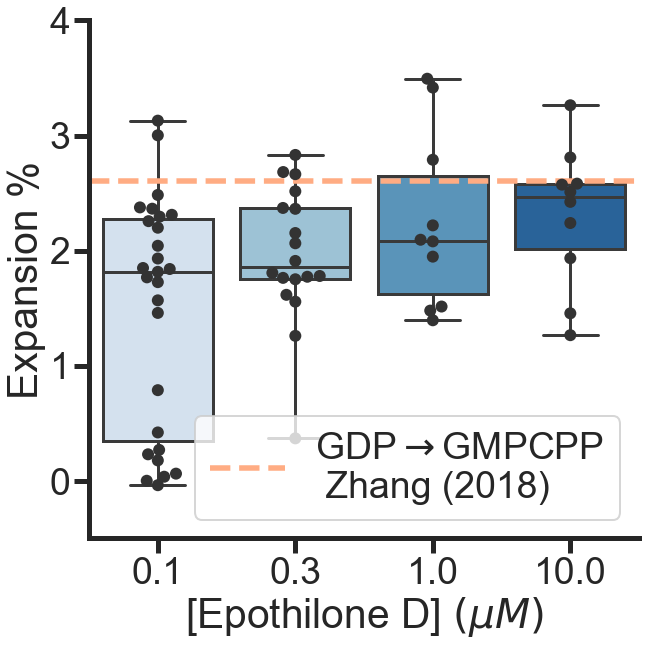

In [131]:
fig, ax = plt.subplots(1,1,figsize=(10,10))

#rect = 0,0,1,1 # create an rectangle for the new axis
#log_ax = fig.add_axes(rect) # create a new axis (or use an existing one)
#log_ax.set_xscale("log") # log first

ax = sns.boxplot(x= taxol, y='Expansion %', data=finalData, whis=np.inf, palette='Blues',linewidth=3)
ax = sns.swarmplot(x=taxol, y='Expansion %', data=finalData, color=".2", size=12)

ax.axhline(y = nogales2018, color = lightorange ,linestyle="--", linewidth=5.5, label='GDP'r'$\rightarrow$''GMPCPP \n Zhang (2018)')
#plt.xlim(0.1,10)

ax.set_ylim(-0.5,4)
ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(taxol)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


plt.savefig(path/('expansion_'+date_today+'.svg'))

In [132]:
(1- 81.76/83.95)*100

2.608695652173909

In [63]:
finalData.groupby([taxol,'CH','Date']).size()

NameError: name 'finalData' is not defined

In [134]:
finalData.groupby(taxol).size()

[Epothilone D] $(\mu M)$
0.1     27
0.3     18
1.0     10
10.0    10
dtype: int64

In [100]:
np.logspace(-2, 1, 7, endpoint=True)

array([ 0.01      ,  0.03162278,  0.1       ,  0.31622777,  1.        ,
        3.16227766, 10.        ])

## change drug name to merge##

In [136]:
finalData=finalData.rename({taxol: drug}, axis=1)
finalData[drugtype] = 'Epothilone D'

In [137]:
finalData

,Curve Name,Curve Length (um),[Drug] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH,Expansion %,Drug Type
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1,2.581796,Epothilone D
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1,2.509758,Epothilone D
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1,1.455021,Epothilone D
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1,2.573112,Epothilone D
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1,2.423518,Epothilone D
...,...,...,...,...,...,...,...,...,...
131,CURVE 5,7.561172,0.1,0,None,2023-02-02,2,2.294891,Epothilone D
133,CURVE 6,5.221171,0.1,0,None,2023-02-02,2,0.176963,Epothilone D
135,CURVE 7,7.613788,0.1,0,None,2023-02-02,2,1.567684,Epothilone D
137,CURVE 8,6.560230,0.1,0,None,2023-02-02,2,1.725892,Epothilone D


In [138]:
name = 'expansion_plain_to_EpoD_data-for-merge_'+date_today +'_MasterSheet.csv'
finalData.to_csv(path/(name), encoding='utf-8', index=False)

## Merge different drugs ##

In [116]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [157]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if str(i).rfind('merge') != -1 if str(i).rfind('csv') != -1 if str(i).rfind('exp') != -1]
files

[WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/expansion_plain_to_Doce_data-for-merge_2023-01-17_MasterSheet.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/expansion_plain_to_EpoD_data-for-merge_2023-02-03_MasterSheet.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/expansion_plain_to_Pacli_data-for-merge_2023-01-17_MasterSheet.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/expansion_plain_to_SiR_data-for-merge_2023-01-17_MasterSheet.csv')]

In [158]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

In [159]:
#order drugs
Type_order = ['Paclitaxel', 'Docetaxel','Epothilone D','SiR-tubulin']
category_Type = CategoricalDtype(Type_order, ordered=True,) 
joindata[drugtype] = joindata[drugtype].astype(category_Type)
joindata = joindata.sort_values(by=[drugtype, drug])

In [160]:
joindata.to_csv(path/('merge-drug-data-on_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,CH,Curve Length (um),Curve Name,DCX Type,Date,Drug Type,Expansion %,[DCX] $(n M)$,[Drug] $(\mu M)$
157,CH1,22.776211,CURVE 1,NaN,2022-05-25,Paclitaxel,-0.004813,NaN,0.0
158,CH1,11.922274,CURVE 2,NaN,2022-05-25,Paclitaxel,0.027885,NaN,0.0
159,CH1,21.999505,CURVE 3,NaN,2022-05-25,Paclitaxel,0.002003,NaN,0.0
160,CH1,19.814312,CURVE 5,NaN,2022-05-25,Paclitaxel,-0.085216,NaN,0.0
161,CH1,6.845359,CURVE 6,NaN,2022-05-25,Paclitaxel,0.045181,NaN,0.0
...,...,...,...,...,...,...,...,...,...
219,2,8.566150,CURVE 3,None,2022-11-10,SiR-tubulin,-0.008393,0.0,10.0
220,2,9.428532,CURVE 4,None,2022-11-10,SiR-tubulin,0.018932,0.0,10.0
221,2,7.548724,CURVE 5,None,2022-11-10,SiR-tubulin,-0.027145,0.0,10.0
222,2,10.715951,CURVE 6,None,2022-11-10,SiR-tubulin,0.499633,0.0,10.0


## Load merged drugs ##

In [64]:
askfile = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the folder on ONE date you want to process
filepath = Path(askfile)
filename = filepath.stem
filepath, filename

(WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Expansion_Data_Sheets/merge-drug-data-on_2023-02-03_MasterSheet.csv'),
 'merge-drug-data-on_2023-02-03_MasterSheet')

In [65]:
mydir= filepath.parents[0]

In [66]:
joindata = pd.read_csv(filepath, encoding='utf-8')

In [71]:
joindata.groupby(['Drug Type',drug,'CH']).size()

Drug Type     [Drug] $(\mu M)$  CH 
Docetaxel     0.1               1       7
                                2       8
              0.3               1       6
                                2       4
                                3       8
                                4      10
              1.0               3      11
                                4       9
Epothilone D  0.1               1       3
                                2      12
                                3       5
                                4       7
              0.3               1      10
                                2       8
              1.0               3       7
                                4       3
              10.0              1       7
                                2       3
Paclitaxel    0.0               CH1    23
              0.1               CH1     5
                                CH2     7
              0.3               CH2     4
                                CH3     

In [72]:
dcxT = 'WT'
drugT = 'Epothilone D'

resultsN = joindata[(joindata['Drug Type'] == drugT)]


joindata.groupby(['Drug Type',drug]).size()

Drug Type     [Drug] $(\mu M)$
Docetaxel     0.1                 15
              0.3                 28
              1.0                 20
Epothilone D  0.1                 27
              0.3                 18
              1.0                 10
              10.0                10
Paclitaxel    0.0                 23
              0.1                 12
              0.3                 11
              1.0                  8
              10.0                10
SiR-tubulin   10.0                32
dtype: int64

In [9]:
joindata = joindata[joindata[drugtype] == 'Paclitaxel']
meandata = joindata.groupby(drug).mean()
stddata = joindata.groupby(drug).std()
x = meandata.index.values
y = meandata['Expansion %'].values
yerr = stddata['Expansion %'].values

In [10]:
def hillEQ(x, n, kd):
    return  nogales2018 * np.power(x, n)/(kd + np.power(x, n))


In [11]:
coeff, var_matrix = sp.optimize.curve_fit(hillEQ,x,y)
n, kd =coeff
n, kd

(2.964076972668361, 0.04163178486343659)

In [12]:
variance = np.diagonal(var_matrix) #Refer [3]
SE = np.sqrt(variance) #Refer [4]
SE

array([1.22185117, 0.06132388])

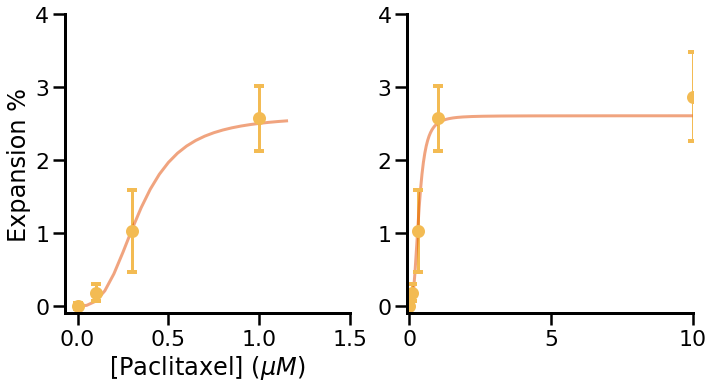

In [75]:
scattersize = 9
cap = 5

fig, ax = plt.subplots(1,2,figsize=(11.25,5.5))

x0 = np.arange(0, 1.2, 0.05)
ax[0].plot(x0, hillEQ(x0, n, kd),color = '#E34A00', lw=3,ls= '-',alpha = 0.5)
ax[0].set_xlabel(taxol)
ax[0].set_yticks(np.arange(0, 4.1, 1))
ax[0].set_xticks(np.arange(0, 1.6, 0.5))
ax[0].set_ylabel('Expansion %')
ax[0].set_xlim(-0.07,1.5)
ax[0].set_ylim(-0.1,4.0)

x0 = np.arange(0, 10, 0.05)
ax[1].plot(x0, hillEQ(x0, n, kd),color = '#E34A00', lw=3,ls= '-',alpha = 0.5)
ax[1].set_yticks(np.arange(0, 4.1, 1))
ax[1].set_xticks(np.arange(0, 10.1, 5))
ax[1].set_xlim(-0.07,10)
ax[1].set_ylim(-0.1,4.0)

for i in np.arange(len(ax)):
        
    ax[i].errorbar(x , y , yerr= yerr , fmt='',marker='o', markersize=scattersize,capsize = cap,
                                  markeredgewidth=4,color='#F3BB53', alpha = 1, ls='')

    #x0 = np.arange(0, 10, 0.05)
    #ax[i].plot(x0, hillEQ(x0, n, kd),color = blue, lw=3,ls= '-',alpha = 0.5)

    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['left'].set_lw(3)
    ax[i].spines['bottom'].set_lw(3)
#ax.tick_params(axis='both', width = 3.5, length = 7)

#ax.legend((r'$n=2.96 \pm 1.22$' '\n' r'$kd=0.042 \pm 0.061$',),loc='lower right',title='Hill Equation')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.savefig(mydir/('expHillfit_'+date_today+'.svg'))

In [46]:
logx = np.log(x[1:-1])
normy = y[1:-1]/nogales2018
logy = np.log(normy/(1-normy))

normyerr = yerr[1:-1]/nogales2018
logyerr = (1/normy)*(1/(1-normy))*normyerr


In [47]:
mydir

WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Expansion_Data_Sheets')

In [74]:
p, cov = np.polyfit(logx, logy, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

p, SElin

(array([2.9788524, 3.8860478]), array([0.54567775, 0.81860445]))

In [78]:
R2S(logy,logx*p[0]+p[1])

0.967533133859834

In [49]:
m,b=p
np.exp(-b), np.exp(-b)*SElin[1]

(0.020526310034830523, 0.016802928804252062)

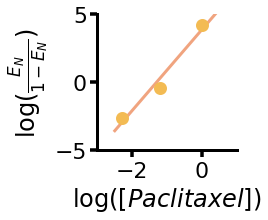

In [62]:
fig, ax = plt.subplots(1,1,figsize=(2.5,2.5))
ax.errorbar(logx , logy , yerr= 0, fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4,color='#F3BB53', alpha = 1, ls='')

x0 = np.arange(-2.5, 0.5, 0.05)
ax.plot(x0, x0*m+b,color = '#E34A00', lw=3,ls= '-',alpha = 0.5)

ax.set_ylim(-5,5)
ax.set_xlim(-3,1)
ax.set_xlabel(r'$\log([Paclitaxel])$')
#ax.set_xticks(np.arange(0, 22.1, 2))
#ax.set_yticks(np.arange(0, 150.1, 25))
ax.set_ylabel(r'$\log(\frac{E_N}{1-E_N})$') 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)

#ax.legend((r'$n=2.98 \pm 0.54$' '\n' r'$kd=0.020 \pm 0.017$',),loc='upper left',title='Hill Equation')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.savefig(mydir/('logexpHillfit_'+date_today+'.svg'))

C:\Users\Brouhard Lab\AppData\Roaming\Python\Python37\site-packages\seaborn\categorical.py:1296: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


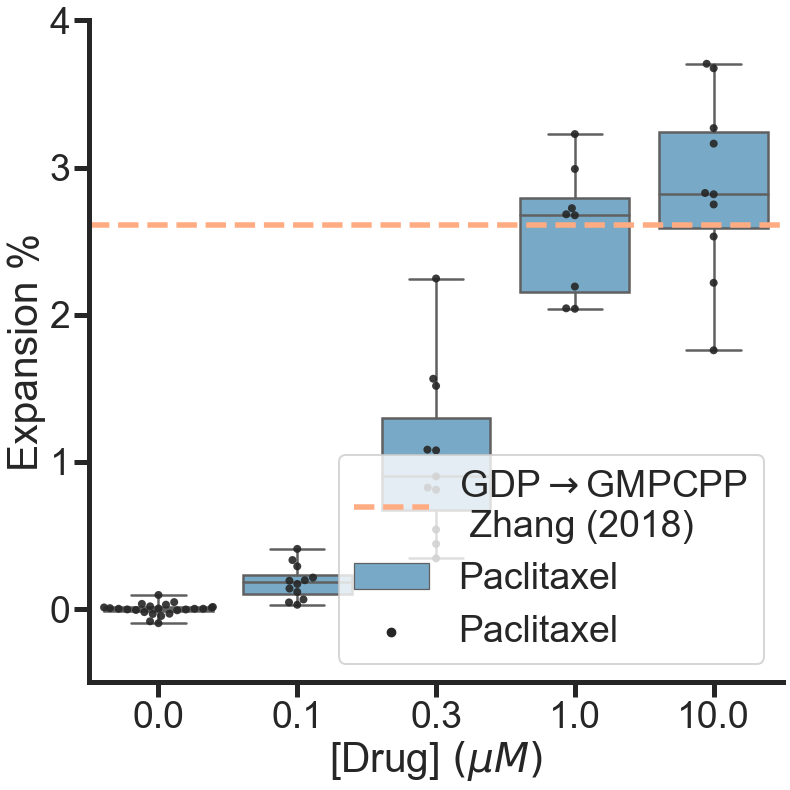

In [57]:
fig, ax = plt.subplots(1,1,figsize=(12,12))

#rect = 0,0,1,1 # create an rectangle for the new axis
#log_ax = fig.add_axes(rect) # create a new axis (or use an existing one)
#log_ax.set_xscale("log") # log first

ax = sns.boxplot(x= drug, y='Expansion %',hue=drugtype, data=joindata, whis=np.inf,linewidth=2.5, palette='Blues')
ax = sns.swarmplot(x=drug, y='Expansion %',hue=drugtype, data=joindata, color=".2", size=8, dodge=True, alpha=0.9)

ax.axhline(y = nogales2018, color = lightorange ,linestyle="--", linewidth=5.5, label='GDP'r'$\rightarrow$''GMPCPP \n Zhang (2018)')
#plt.xlim(0.1,10)

ax.set_ylim(-0.5,4)
ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(drug)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


#plt.savefig(path/('mergedrugs_'+date_today+'.svg'))